# Homework

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

## Problems [Part 1](./01_Catch_Motion.md)

**1.** Instead of using $\frac{\Delta v}{\Delta t}$, you can use the [numpy polyfit](https://docs.scipy.org/doc/numpy/reference/generated/numpy.polyfit.html) to determine the acceleration of the ball. 

a. Use your coordinates from the saved .npz file you used above to load your projectile motion data

```python
npz_coords = np.load('projectile_coords.npz')
t = npz_coords['t']
x = npz_coords['x']
y = npz_coords['y']
```

c. Use a second-order polynomial fit for x- and y- vs t. What is acceleration now?

d. Plot the polyfit lines for position and time (2 figures) with the
positions vs time. Do the fits match the data?

**2.** Not only can you measure acceleration of objects that you track, you can look at other physical constants like [coefficient of restitution](https://en.wikipedia.org/wiki/Coefficient_of_restitution), $e$ . 

     During a collision with the ground, the coefficient of restitution is
     
     $e = -\frac{v_{y}'}{v_{y}}$ . 
     
     Where $v_y'$ is y-velocity perpendicular to the ground after impact
     and $v_y$ is the y-velocity before impact. 
     
a. Calculate $v_y$ and plot as a function of time from the data `'../data/fallingtennisball02.txt'`

b. Find the locations when $v_y$ changes rapidly i.e. the impact locations. Get the maximum and minimum velocities closest to the impact location. _Hint: this can be a little tricky. Try slicing the data to include one collision at a time before using  the `np.min` and `np.max` commands._

c. Calculate the $e$ for each of the three collisions

## Problems [Part 2](./02_Step_Future.md)

**1.** Integrate the `fall_drag` equations for a tennis ball and a [lacrosse ball](https://en.wikipedia.org/wiki/Lacrosse_ball) with the same initial conditions as above. Plot the resulting height vs time. 

_Given:_ y(0) = 10 m, v(0) = 0 m/s

|ball| diameter | mass|
|---|---|---|
|tennis| $6.54$–$6.86 \rm{cm}$ |$56.0$–$59.4 \rm{g}$|
|lacrosse| $6.27$–$6.47 \rm{cm}$ |$140$–$147 \rm{g}$|

Is there a difference in the two solutions? At what times do the tennis ball and lacrosse balls reach the ground? Which was first?

**2.** A pendulum that swings in small angles follows a $\theta_0 \cos
\omega t$ where $\theta_0$ is the initial angle that its released from
rest and $\omega$ is the natural frequency of the pendulum. The
underlying differential equation is 

$\ddot{\theta} = -\frac{g}{L}\cos\theta$

a. Create a `pendulum` fuction that returns $[\dot{\theta},~\ddot{\theta}]$ when its given $[\theta,~\dot{\theta}]$

b. Integrate the `pendulum` function for 2 periods of oscillation given initial conditions of $y_0 = [\frac{\pi}{6}~rad,~0~rad/s]$, $g = 9.81~m/s^2$, and $L = 1~m$. Plot the angle as a function of time, $\theta-vs-t$.

In [2]:
def pendulum(y, g = 9.81, L = 1):
  '''Computes the right-hand side of the differential equation
  for the fall of a ball, with drag, in SI units.

  Arguments
  ----------    
  state : array of two dependent variables [theta dtheta]^T
  g : acceleration due to gravity
  L : length of pendulum 
  Returns
  -------
  derivs: array of two derivatives [dtheta (-g/L*sin(theta))]^T
  '''
  theta, dtheta = y
  derivs = np.array([dtheta, 0]) # your work here (replace the 0 with the differential equation
  return derivs

## Problems [Part 3](./03_Get_Oscillations.md)

**1.** Show that the implicit Heun's method has the same second order convergence as the Modified Euler's method. _Hint: you can use the same code from above to create the log-log plot to get the error between $2\cos(\omega t)$ and the `heun_step` integration. Use the same initial conditions x(0) = 2 m and v(0)=0m/s and the same RHS function, `springmass`.

![A lumped mass connected to a spring and
damper](../images/damped-spring.png)

**2.** In the image above, you have a spring, mass, _and damper_. A damper is designed to slow down a moving object. These devices are typical in automobiles, mountain bikes, doors, any place where oscillations may not be desired, but motion is required. The new differential equation, if F(t)=0, that results from this addition is

$\ddot{x} = -\frac{b}{m}\dot{x} -\frac{k}{m}x$

or keeping our _natural frequency_ above, 

$\ddot{x} = -\zeta\omega\dot{x} -\omega^2x$

where $\zeta$ is a new constant called the __damping ratio__ of a system. When $\zeta\gt 1$, there are no oscillations and when $0<\zeta<1$ the system oscillates, but decays to v=0 m/s eventually. 

Create the system of equations that returns the right hand side (RHS) of the state equations, e.g. $\mathbf{\dot{y}} = f(\mathbf{y}) = RHS$

Use $\omega = 2$ rad/s and $\zeta = 0.2$.

In [3]:
def smd(state):
    '''Computes the right-hand side of the spring-mass-damper
    differential equation, without friction.
    
    Arguments
    ---------   
    state : array of two dependent variables [x, v]^T
    
    Returns 
    -------
    derivs: array of two derivatives [v, zeta*w*v - w*w*x]^T
    '''
    ## your work here ##
    
    return derivs

**3.** Use three methods to integrate your `smd` function for 3 time periods of oscillation and initial conditions x(0)=2 m and v(0)=0 m/s. Plot the three solutions on one graph with labels. 

a. Euler integration

b. second order Runge Kutta method (modified Euler method)

c. the implicit Heun's method

How many time steps does each method need to converge to the same results? _Remember that each method has a certain convergence rate_

## Problems [Part 3](./04_Getting_to_the_root.md)

**1.** One of the main benefits of a bracketing method is the stability of solutions. Open methods are not always stable. Here is an example. One way engineers and data scientists model the probability of failure is with a [sigmoid function e.g. this Challenger O-ring case study](https://byuistats.github.io/M325_Hathaway/textbook/challengerLogisticReg.html)

$$\begin{equation}
    \sigma(T) = \frac{e^{a_0-a_1 T}}{1+e^{a_0-a_1 T}}
\end{equation}$$

The Challenger explosion was a terrible incident that occurred due to the failure of an O-ring. The post-mortem data analysis showed that at low temperatures the O-rings were brittle and more likely to fail. You can use the function $\sigma(T)$ to determine the point at which there is a 50\% chance of O-ring failure. Using the pass-fail data, the two constants are

$a_0 = 15.043$

$a_1 = 0.232$

a. Plot the function $\sigma(T)$ for $T=0-100^{o}F$. Where do you see the function cross 50\% (0.5)?

b. Create two functions `f_T` and `dfdT` where `f_T`=$f(T)=\sigma(T) - 0.5$ and `dfdT`=$\frac{df}{dT}$

c. Use the `incsearch` and `newtraph` functions to find the root of f(T). When does Newton-Raphson fail to converge? Why does it fail? _Hint: if you're stuck here, take a look at this [youtube video finding an interval of convergence for the Newton-Raphson method](https://youtu.be/zyXRo8Qjj0A). Look at the animation of how the method converges and diverges._

**2.** In the [Shooting Method
   example](https://cooperrc.github.io/computational-mechanics/module_03/04_Getting_to_the_root.html#shooting-method), you determined the initial velocity after the first
   bounce by specifying the beginning y(0) and end y(T) for an object
   subject to gravity and drag. Repeat this analysis for the time period
   just after the second bounce and just before the third bounce. The
   indices are given below for t[1430:2051] = 1.43-2.05 seconds.

a. What is the velocity just after the second bounce?

b. What is the coefficient of restitution for the second bounce? _Hint: use the ratio of the last velocity from above to the initial velocity calculated here._

1.4300000000009008 2.051000000004969


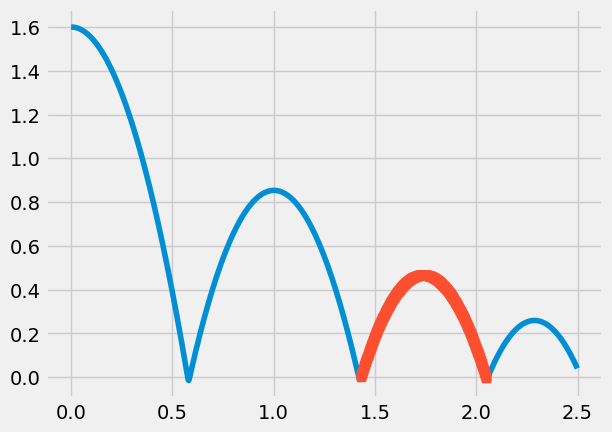

In [4]:
filename = '../data/fallingtennisball02.txt'
t, y = np.loadtxt(filename, usecols=[0,1], unpack=True)
i0=1430
ie=2051
print(t[i0],t[ie])
plt.plot(t,y)
plt.plot(t[i0:ie],y[i0:ie],'s')